# Analisis de texto con spaCy sobre descripciones de peliculas TMDB

Este cuaderno inicia el trabajo de forma incremental y basada en evidencia. En esta primera etapa primero se carga el dataset, se inspecciona su estructura y se documentan observaciones iniciales que despues nos ayudaran a decidir que rasgos extraer con spaCy.

El objetivo final es extraer y explicar caracteristicas linguisticas como categorias gramaticales, entidades nombradas y vectores de palabras, pero en este punto solo construiremos una base reproducible para ese analisis.


In [1]:
import kagglehub
import pandas as pd
import spacy
from pathlib import Path
from IPython.display import display


In [2]:
dataset_dir = Path(kagglehub.dataset_download('dhruv7302/tmdb-10000-movies-dataset'))
csv_path = dataset_dir / 'TMDB_10000_Movies.csv'
df = pd.read_csv(csv_path)

print(f'Ruta del archivo: {csv_path}')
print(f'Filas y columnas: {df.shape}')
print()
print('Columnas disponibles:')
print(df.columns.tolist())
print()
print('Tipos de datos:')
print(df.dtypes)
print()
print('Valores nulos por columna:')
print(df.isna().sum())
print()
print('Primeros registros:')
display(df.head())

eda_texto = pd.DataFrame({
    'columna': ['Title', 'Description', 'Genres'],
    'longitud_promedio': [
        df['Title'].fillna('').str.len().mean(),
        df['Description'].fillna('').str.len().mean(),
        df['Genres'].fillna('').str.len().mean()
    ],
    'longitud_minima': [
        df['Title'].fillna('').str.len().min(),
        df['Description'].fillna('').str.len().min(),
        df['Genres'].fillna('').str.len().min()
    ],
    'longitud_maxima': [
        df['Title'].fillna('').str.len().max(),
        df['Description'].fillna('').str.len().max(),
        df['Genres'].fillna('').str.len().max()
    ]
})

print('Resumen basico de longitud textual:')
display(eda_texto)


Ruta del archivo: /home/jheisonmblivecom/.cache/kagglehub/datasets/dhruv7302/tmdb-10000-movies-dataset/versions/1/TMDB_10000_Movies.csv
Filas y columnas: (10000, 4)

Columnas disponibles:
['Unnamed: 0', 'Title', 'Description', 'Genres']

Tipos de datos:
Unnamed: 0     int64
Title            str
Description      str
Genres           str
dtype: object

Valores nulos por columna:
Unnamed: 0     0
Title          0
Description    2
Genres         0
dtype: int64

Primeros registros:


,Unnamed: 0,Title,Description,Genres
0,0,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...","['Drama', 'Crime']"
1,1,The Shawshank Redemption,Framed in the 1940s for the double murder of h...,"['Drama', 'Crime']"
2,2,The Godfather Part II,In the continuing saga of the Corleone crime f...,"['Drama', 'Crime']"
3,3,Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second...","['Comedy', 'Drama', 'Romance']"
4,4,Schindler's List,The true story of how businessman Oskar Schind...,"['Drama', 'History', 'War']"


Resumen basico de longitud textual:


,columna,longitud_promedio,longitud_minima,longitud_maxima
0,Title,15.7392,1,83
1,Description,271.6756,0,1000
2,Genres,27.8542,2,106


## Observaciones del EDA inicial

- Dataset: 10000 filas x 4 columnas: `Unnamed: 0`, `Title`, `Description`, `Genres`.
- `Unnamed: 0` es indice heredado del CSV, sin valor analitico. Se ignora en el analisis linguistico.
- Nulos: `Description` con 2 nulos sobre 10000 (0.02%). `Title` y `Genres` sin nulos.
- Longitud promedio: `Title` ~16 caracteres, `Description` ~272 caracteres, `Genres` ~28 caracteres. `Description` concentra la senal textual; `Title` es muy corto para POS/NER/vector, `Genres` es etiqueta estructurada en formato string de lista.
- Rango `Description`: minimo 0, maximo 1000 caracteres. Hay descripciones vacias ligadas a los nulos que deben filtrarse antes de pasar por spaCy.
- Idioma del corpus: ingles. Se requiere modelo ingles de spaCy para POS, NER y vectores.

### Decisiones

- Columna de trabajo: `Description`. `Title` solo como apoyo para validar entidades.

### Preguntas que guiaran el analisis

- P1: **Cuales son las principales tematicas del dataset a partir del vocabulario de las descripciones?**
- P2: **Quienes, donde y cuando ocurren las historias contadas en las descripciones?**

### P1.1: Que roles gramaticales dominan una descripcion?

Para responder P1 empezamos por POS sobre `Description`, no sobre `Title`.

Tomamos una sola descripcion real y separamos NOUN y VERB para ver que es hecho/tema y que es accion. Este ejemplo nos dira si POS sirve para agrupar descripciones por objeto antes de contar frecuencias en todo el corpus.

In [3]:
import spacy

nlp = spacy.load('en_core_web_md')
sample = df.loc[df['Description'].fillna('').str.len() > 0, ['Title', 'Description']].iloc[0]
doc = nlp(sample['Description'])

print(f"Titulo: {sample['Title']}")
print(f"Descripcion: {sample['Description']}")
print()

rows = [(t.text, t.pos_, t.tag_, t.dep_) for t in doc]
pos_df = pd.DataFrame(rows, columns=['token', 'pos', 'tag', 'dep'])
display(pos_df.head(20))

print()
print('Conteo POS en esta descripcion:')
print(pos_df['pos'].value_counts())

Titulo: The Godfather
Descripcion: Spanning the years 1945 to 1955, a chronicle of the fictional Italian-American Corleone crime family. When organized crime family patriarch, Vito Corleone barely survives an attempt on his life, his youngest son, Michael steps in to take care of the would-be killers, launching a campaign of bloody revenge.



,token,pos,tag,dep
0,Spanning,VERB,VBG,ROOT
1,the,DET,DT,det
2,years,NOUN,NNS,dobj
3,1945,NUM,CD,nummod
4,to,ADP,IN,prep
5,1955,NUM,CD,pobj
6,",",PUNCT,",",punct
7,a,DET,DT,det
8,chronicle,NOUN,NN,dobj
9,of,ADP,IN,prep



Conteo POS en esta descripcion:
pos
NOUN     14
PUNCT     9
DET       6
ADP       6
ADJ       6
VERB      5
PROPN     4
NUM       2
PRON      2
AUX       2
SCONJ     1
ADV       1
PART      1
Name: count, dtype: int64


### P1.2: Que sustantivos dominan las 10000 descripciones?

Pasamos del ejemplo a todo el corpus. Contamos lemas NOUN y PROPN en `Description`.

Sobre stopwords: si vale la pena como en hoteles, pero con orden distinto. Primero se etiqueta con POS, despues se filtra. Se conserva solo alfabetico, no stop con `is_stop`, longitud mayor a 2, en minuscula por lema. Asi el conteo muestra objeto tematico y no determinantes ni preposiciones.

Descripciones no vacias: 9998 de 10000


,sustantivo,frecuencia
0,life,2079
1,man,1330
2,year,1257
3,world,1128
4,family,1119
5,friend,1055
6,woman,865
7,love,804
8,time,711
9,story,706


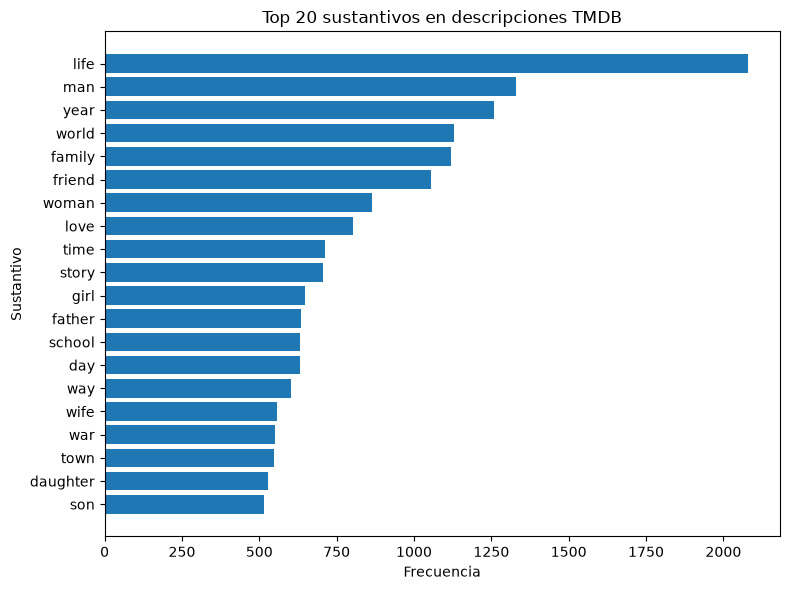

Vocabulario sustantivo distinto: 17488


In [4]:
from collections import Counter
import matplotlib.pyplot as plt

texts = df['Description'].fillna('').tolist()
texts = [t for t in texts if t.strip() != '']
print(f'Descripciones no vacias: {len(texts)} de {len(df)}')

counter = Counter()
for doc in nlp.pipe(texts, batch_size=100, disable=['parser', 'ner']):
    for t in doc:
        if t.pos_ in ('NOUN', 'PROPN') and t.is_alpha and not t.is_stop and len(t.lemma_) > 2:
            counter[t.lemma_.lower()] += 1

top = counter.most_common(20)
top_df = pd.DataFrame(top, columns=['sustantivo', 'frecuencia'])
display(top_df)

plt.figure(figsize=(8, 6))
plt.barh(top_df['sustantivo'][::-1], top_df['frecuencia'][::-1])
plt.xlabel('Frecuencia')
plt.ylabel('Sustantivo')
plt.title('Top 20 sustantivos en descripciones TMDB')
plt.tight_layout()
plt.show()

print(f'Vocabulario sustantivo distinto: {len(counter)}')

### P1.3: Que acciones dominan las descripciones?

Complementamos P1 con VERB. Mismo filtro que en NOUN: lema en minuscula, alfabetico, no stop, longitud mayor a 2. Asi separamos accion narrativa de auxiliares y muletillas.

,verbo,frecuencia
0,find,1747
1,live,708
2,take,706
3,discover,696
4,try,675
5,come,622
6,meet,611
7,begin,610
8,turn,564
9,leave,552


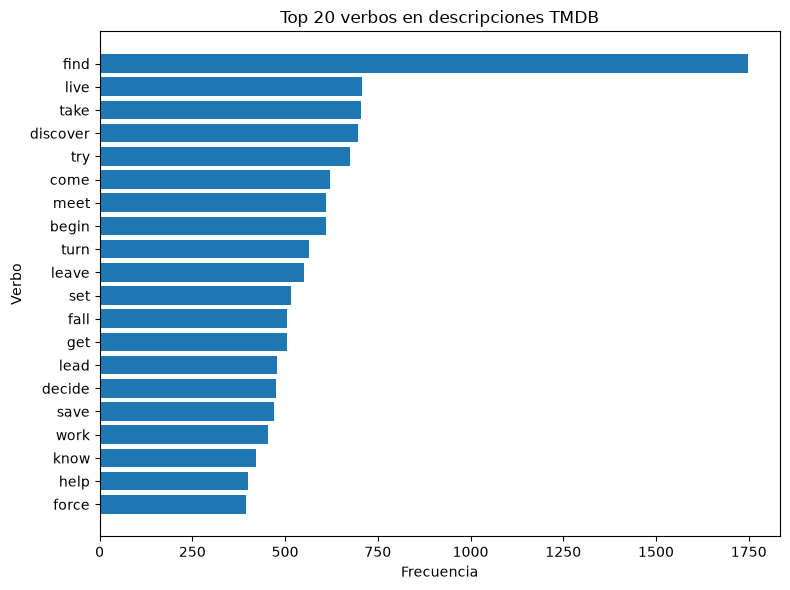

Vocabulario verbal distinto: 2856


In [5]:
verb_counter = Counter()
for doc in nlp.pipe(texts, batch_size=100, disable=['parser', 'ner']):
    for t in doc:
        if t.pos_ == 'VERB' and t.is_alpha and not t.is_stop and len(t.lemma_) > 2:
            verb_counter[t.lemma_.lower()] += 1

top_v = verb_counter.most_common(20)
top_v_df = pd.DataFrame(top_v, columns=['verbo', 'frecuencia'])
display(top_v_df)

plt.figure(figsize=(8, 6))
plt.barh(top_v_df['verbo'][::-1], top_v_df['frecuencia'][::-1])
plt.xlabel('Frecuencia')
plt.ylabel('Verbo')
plt.title('Top 20 verbos en descripciones TMDB')
plt.tight_layout()
plt.show()

print(f'Vocabulario verbal distinto: {len(verb_counter)}')

### P1.4: Que objetos compuestos rompe el unigrama?

El conteo de P1.2 parte crime family en crime y family por separado y pierde el objeto real. Aqui contamos bigramas adyacentes de tipo ADJ+NOUN y NOUN+NOUN sobre Description para recuperar colocaciones tematicas.

,bigrama,frecuencia
0,new york,305
1,high school,243
2,good friend,194
3,young man,169
4,young woman,157
5,world war,137
6,los angeles,133
7,true story,114
8,york city,99
9,serial killer,97


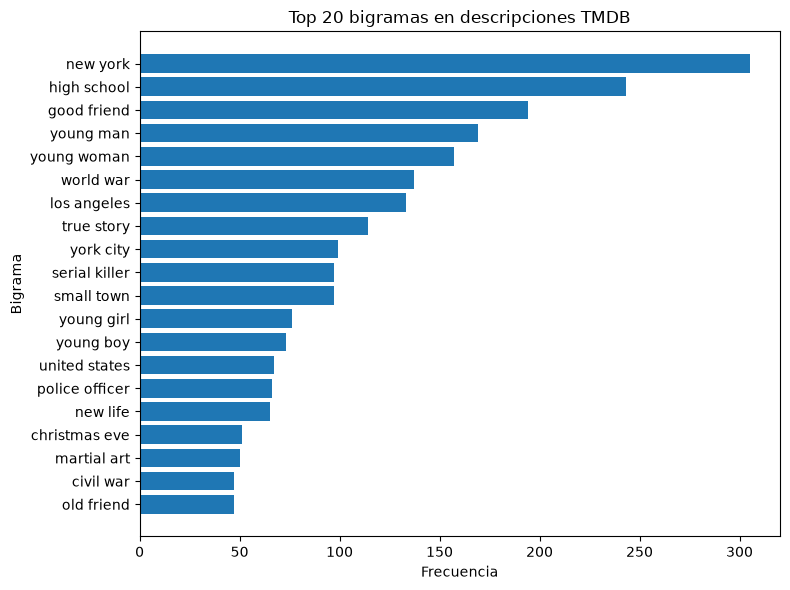

In [6]:
bigram_counter = Counter()
for doc in nlp.pipe(texts, batch_size=100, disable=['parser', 'ner']):
    for i in range(len(doc) - 1):
        a, b = doc[i], doc[i + 1]
        if a.pos_ in ('NOUN', 'PROPN', 'ADJ') and b.pos_ in ('NOUN', 'PROPN'):
            if a.is_alpha and b.is_alpha and not a.is_stop and not b.is_stop:
                if len(a.lemma_) > 2 and len(b.lemma_) > 2:
                    bigram_counter[f'{a.lemma_.lower()} {b.lemma_.lower()}'] += 1

top_b = bigram_counter.most_common(20)
top_b_df = pd.DataFrame(top_b, columns=['bigrama', 'frecuencia'])
display(top_b_df)

plt.figure(figsize=(8, 6))
plt.barh(top_b_df['bigrama'][::-1], top_b_df['frecuencia'][::-1])
plt.xlabel('Frecuencia')
plt.ylabel('Bigrama')
plt.title('Top 20 bigramas en descripciones TMDB')
plt.tight_layout()
plt.show()

### P2.1: Quienes, donde y cuando aparecen en las historias?

Respondemos P2 con NER sobre `Description` cruda, no sobre listas de sustantivos. NER necesita la frase completa para usar mayusculas y contexto.

Contamos menciones por etiqueta y mostramos las mas frecuentes por tipo para ver si dominan personas, lugares o fechas.

,etiqueta,menciones
0,PERSON,15702
1,GPE,4845
2,ORG,4206
3,DATE,3522
4,CARDINAL,2819
5,NORP,2331
6,LOC,897
7,ORDINAL,577
8,TIME,415
9,EVENT,391


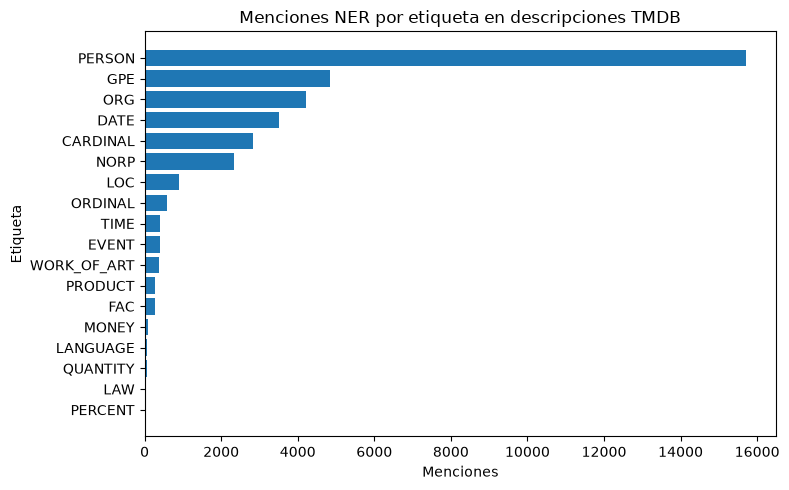

,mencion,etiqueta,frecuencia
0,two,CARDINAL,716
1,one,CARDINAL,536
2,first,ORDINAL,376
3,three,CARDINAL,315
4,American,NORP,256
5,Two,CARDINAL,228
6,Earth,LOC,191
7,New York,GPE,182
8,Paris,GPE,166
9,French,NORP,154


Descripciones procesadas: 9998
Menciones totales: 36904


In [7]:
label_counter = Counter()
mention_counter = Counter()
for doc in nlp.pipe(texts, batch_size=50):
    for ent in doc.ents:
        label_counter[ent.label_] += 1
        mention_counter[(ent.text.strip(), ent.label_)] += 1

label_df = pd.DataFrame(label_counter.most_common(), columns=['etiqueta', 'menciones'])
display(label_df)

plt.figure(figsize=(8, 5))
plt.barh(label_df['etiqueta'][::-1], label_df['menciones'][::-1])
plt.xlabel('Menciones')
plt.ylabel('Etiqueta')
plt.title('Menciones NER por etiqueta en descripciones TMDB')
plt.tight_layout()
plt.show()

top_mentions = pd.DataFrame(
    [(t, l, c) for (t, l), c in mention_counter.most_common(20)],
    columns=['mencion', 'etiqueta', 'frecuencia']
)
display(top_mentions)

print(f'Descripciones procesadas: {len(texts)}')
print(f'Menciones totales: {sum(label_counter.values())}')

### P2.2: Que nos dice NER de P2?

36.904 menciones en 9.998 descripciones. PERSON domina con 15.702, seguido de GPE 4.845, ORG 4.206, DATE 3.522, CARDINAL 2.819 y NORP 2.331.

El top de menciones esta lleno de CARDINAL y ORDINAL genericos como two, one, first y three. No son temas, son conteos dentro de la trama. El valor esta en GPE y NORP: New York, Paris, London, Los Angeles, France, American, French y British. Mas ORG como FBI, LOC como Earth, EVENT como World War II y DATE como Christmas.

PERSON no concentra un nombre en el top porque cada pelicula trae sus propios personajes. Eso confirma que NER sirve para quien y donde a nivel agregado, pero el quien especifico pide cruce con NOUN y PROPN por pelicula, no solo conteo global.

### P2.1b: NER semantico sin numeros (refinamiento)

El top general lo copan CARDINAL y ORDINAL como two, one y first. Son conteos de trama, no tema. Aqui miramos solo etiquetas con contenido: PERSON, GPE, ORG, NORP, DATE, LOC, EVENT, WORK_OF_ART, PRODUCT, FAC, LANGUAGE y LAW.

In [8]:
SEM = {'PERSON', 'GPE', 'ORG', 'NORP', 'DATE', 'LOC', 'EVENT', 'WORK_OF_ART', 'PRODUCT', 'FAC', 'LANGUAGE', 'LAW'}

label_sem_df = pd.DataFrame(
    [(l, c) for l, c in label_counter.most_common() if l in SEM],
    columns=['etiqueta', 'menciones']
)
display(label_sem_df)

top_sem = [(t, l, c) for (t, l), c in mention_counter.most_common() if l in SEM][:20]
display(pd.DataFrame(top_sem, columns=['mencion', 'etiqueta', 'frecuencia']))

,etiqueta,menciones
0,PERSON,15702
1,GPE,4845
2,ORG,4206
3,DATE,3522
4,NORP,2331
5,LOC,897
6,EVENT,391
7,WORK_OF_ART,380
8,PRODUCT,280
9,FAC,262


,mencion,etiqueta,frecuencia
0,American,NORP,256
1,Earth,LOC,191
2,New York,GPE,182
3,Paris,GPE,166
4,French,NORP,154
5,London,GPE,133
6,Los Angeles,GPE,129
7,British,NORP,123
8,France,GPE,114
9,FBI,ORG,109


### P2.3: Cruce POS contra NER en vocabulario top

Cruzamos el vocabulario, no frases sueltas. Para cada sustantivo top de P1.2 buscamos si aparece tambien como mencion NER y con que etiqueta dominante. Asi separamos sustantivo tematico comun como life o family de nombre propio como propiamente entidad PERSON o GPE.

In [9]:
from collections import defaultdict

mention_by_lower = defaultdict(Counter)
for (text, label), c in mention_counter.items():
    mention_by_lower[text.lower()][label] += c

rows = []
for lemma, freq in counter.most_common(30):
    label_counts = mention_by_lower.get(lemma, Counter())
    ent_freq = sum(label_counts.values())
    best = label_counts.most_common(1)[0][0] if label_counts else '-'
    rows.append((lemma, freq, ent_freq, best))

cross_df = pd.DataFrame(rows, columns=['sustantivo', 'freq_noun', 'freq_entidad', 'etiqueta_dominante'])
display(cross_df.head(20))

n_ent = (cross_df['freq_entidad'] > 0).sum()
print(f'De los 30 sustantivos top, {n_ent} aparecen tambien como entidad NER.')
print(cross_df[cross_df['freq_entidad'] > 0][['sustantivo', 'freq_noun', 'freq_entidad', 'etiqueta_dominante']].to_string(index=False))

,sustantivo,freq_noun,freq_entidad,etiqueta_dominante
0,life,2079,0,-
1,man,1330,1,WORK_OF_ART
2,year,1257,4,DATE
3,world,1128,0,-
4,family,1119,0,-
5,friend,1055,0,-
6,woman,865,1,ORG
7,love,804,7,WORK_OF_ART
8,time,711,5,ORG
9,story,706,0,-


De los 30 sustantivos top, 6 aparecen tambien como entidad NER.
sustantivo  freq_noun  freq_entidad etiqueta_dominante
       man       1330             1        WORK_OF_ART
      year       1257             4               DATE
     woman        865             1                ORG
      love        804             7        WORK_OF_ART
      time        711             5                ORG
       day        632            10               DATE


### P2.3b: Cruce con lemas (corrige falso negativo)

El cruce anterior comparaba lema POS contra texto crudo de entidad, asi que years como entidad nunca emparejaba con el lema year. Aqui lematizamos cada mencion unica y repetimos el cruce sobre lemas.

In [10]:
from collections import defaultdict

uniq_texts = list({t for (t, _l) in mention_counter})
ent_lemma = {}
for doc, t in zip(nlp.pipe(uniq_texts, batch_size=200, disable=['parser', 'ner']), uniq_texts):
    ent_lemma[t] = ' '.join(x.lemma_.lower() for x in doc) if len(doc) > 1 else (doc[0].lemma_.lower() if len(doc) == 1 else t.lower())

mention_lemma = defaultdict(Counter)
for (t, l), c in mention_counter.items():
    mention_lemma[ent_lemma[t]][l] += c

rows2 = []
for lemma, freq in counter.most_common(30):
    lc = mention_lemma.get(lemma, Counter())
    ef = sum(lc.values())
    best = lc.most_common(1)[0][0] if lc else '-'
    rows2.append((lemma, freq, ef, best))

cross2_df = pd.DataFrame(rows2, columns=['sustantivo', 'freq_noun', 'freq_entidad', 'etiqueta_dominante'])
display(cross2_df.head(20))

n2 = (cross2_df['freq_entidad'] > 0).sum()
print(f'De los 30 sustantivos top, {n2} aparecen como entidad tras lematizar.')
print(cross2_df[cross2_df['freq_entidad'] > 0].to_string(index=False))

,sustantivo,freq_noun,freq_entidad,etiqueta_dominante
0,life,2079,0,-
1,man,1330,1,WORK_OF_ART
2,year,1257,84,DATE
3,world,1128,0,-
4,family,1119,0,-
5,friend,1055,0,-
6,woman,865,1,ORG
7,love,804,7,WORK_OF_ART
8,time,711,5,ORG
9,story,706,0,-


De los 30 sustantivos top, 6 aparecen como entidad tras lematizar.
sustantivo  freq_noun  freq_entidad etiqueta_dominante
       man       1330             1        WORK_OF_ART
      year       1257            84               DATE
     woman        865             1                ORG
      love        804             7        WORK_OF_ART
      time        711             5                ORG
       day        632            25               DATE


### Pausa: que entendimos y que sigue

Hasta aca POS mostro objeto con NOUN y accion con VERB sobre Description. NER sobre texto crudo mostro quien y donde con PERSON y GPE dispersos por pelicula. El cruce mostro que el vocabulario tematico comun y el de entidades viven separados.
Lo siguiente es vectores para agrupar palabras en familias y descripciones en historias parecidas.

### P3.1: Que historias quedan cerca sin usar Genres?

Usamos vectores de documento de `en_core_web_md`. Cada descripcion se vuelve un vector promedio y la cercania coseno mide historias parecidas. Probamos con tres descripciones conocidas y luego buscamos las mas parecidas a The Godfather en una muestra.

In [11]:
demos = df.loc[df['Description'].fillna('').str.len() > 0, ['Title', 'Description']].head(3)
demo_docs = list(nlp.pipe(demos['Description'].tolist()))
print('Similitud entre las 3 primeras descripciones:')
for i in range(len(demo_docs)):
    for j in range(i + 1, len(demo_docs)):
        print(f"{demos.iloc[i]['Title']} <-> {demos.iloc[j]['Title']}: {demo_docs[i].similarity(demo_docs[j]):.3f}")

print()
base_idx = df.loc[df['Description'].fillna('').str.len() > 0].index[0]
base_title = df.loc[base_idx, 'Title']
base_doc = nlp(df.loc[base_idx, 'Description'])
sample = df.loc[df['Description'].fillna('').str.len() > 0].iloc[1:501]

sims = []
for idx, row in zip(sample.index, sample.itertuples()):
    d = nlp(row.Description)
    sims.append((row.Title, float(base_doc.similarity(d))))

sims.sort(key=lambda x: x[1], reverse=True)
print(f'Top 5 parecidas a {base_title} en muestra de 500:')
for t, s in sims[:5]:
    print(f'{s:.3f} - {t}')

Similitud entre las 3 primeras descripciones:
The Godfather <-> The Shawshank Redemption: 0.964
The Godfather <-> The Godfather Part II: 0.913
The Shawshank Redemption <-> The Godfather Part II: 0.915



Top 5 parecidas a The Godfather en muestra de 500:
0.976 - American History X
0.973 - Andrei Rublev
0.972 - M
0.972 - Life Is Beautiful
0.971 - The Usual Suspects


### P3.2: Matriz eficiente con vectores sin stopwords (refinamiento)

La celda anterior procesa fila por fila y la media incluye stopwords, por eso todo queda arriba de 0.90. Aqui precomputamos una matriz normalizada con nlp.pipe y media sin stopwords ni puntuacion. Un solo producto punto da todas las similitudes y escala a 10000 documentos.

In [12]:
import numpy as np

mat_titles = sample['Title'].tolist()
mat_docs = list(nlp.pipe(sample['Description'].tolist(), batch_size=100))

def content_vector(doc):
    toks = [t.vector for t in doc if t.has_vector and not t.is_stop and t.is_alpha]
    return np.mean(toks, axis=0) if toks else doc.vector

M = np.stack([content_vector(d) for d in mat_docs])
M = M / np.linalg.norm(M, axis=1, keepdims=True)
q = content_vector(base_doc)
q = q / np.linalg.norm(q)
scores = M @ q

order = np.argsort(scores)[::-1]
print(f'Top 5 parecidas a {base_title} con vectores sin stopwords:')
for i in order[:5]:
    print(f'{scores[i]:.3f} - {mat_titles[i]}')

print()
print(f'Rango de similitud: min {scores.min():.3f}, media {scores.mean():.3f}, max {scores.max():.3f}')

Top 5 parecidas a The Godfather con vectores sin stopwords:
0.920 - M
0.910 - Life Is Beautiful
0.910 - Se7en
0.906 - The Great Escape
0.904 - American History X

Rango de similitud: min 0.482, media 0.820, max 0.920


## Respuesta P1: de que va el dataset

El dataset va de vinculos y busquedas, no de fechas ni cronicas. Los sustantivos que mas se repiten nombran a la gente cercana: vida, familia, amigos, padre, esposa, hijos. Y los verbos que los mueven son encontrar, descubrir, conocer, intentar, irse y salvar. Por eso la formula tipica es alguien que busca algo o a alguien y en el camino su relacion cambia.

Los bigramas recuperan el objeto compuesto que el unigrama parte: new york, high school, serial killer, small town y police officer muestran escenarios y figuras que el conteo suelto escondia.

Los vectores lo confirman sin usar generos: El Padrino queda cerca de American History X, M y Sospechosos Comunes, o sea el modelo junta crimen y drama solo por como estan contadas las historias.

## Respuesta P2: quienes, donde y cuando

El quien esta repartido: hay mas de quince mil menciones de personas pero ningun nombre domina, cada pelicula trae los suyos, incluso inventados como Corleone que el modelo marca bien como persona porque no verifica si existe, solo la forma de nombre.

El donde si se concentra: Nueva York, Paris, Londres, Los Angeles y Francia, con colectivos como americanos, franceses y britanicos. El cuando aparece en fechas como Navidad y eventos como la Segunda Guerra Mundial, mas FBI como organizacion tipica.

El cruce lo deja claro: familia o vida casi nunca son entidades, son el tema. Las entidades son los nombres que distinguen cada historia.

## Limitaciones

Los conteos como two u one inflan NER sin ser tema. Palabras comunes como Love o Time a veces se etiquetan mal como obra u organizacion. Las similitudes de documento salen altas y vale el orden, no el valor. En palabra aislada el modelo dio vectores identicos para pares como life y world, por eso los vectores se usaron a nivel descripcion.

## Conclusiones

El dataset TMDB va de vinculos y busquedas: la familia y los allegados como tema, encontrar y descubrir como accion. NER muestra personajes repartidos por pelicula y lugares concentrados en Estados Unidos y Europa. Los vectores juntan historias afines sin usar generos. Con POS, NER y vectores el texto queda convertido en rasgos interpretables para perfilar tematica, extraer protagonistas y lugares, y recomendar peliculas por sinopsis.